# Ukrainian ASR: Whisper Fine-tuning on Toronto Dataset

Pipeline:
1. Evaluate baseline `openai/whisper-small` on the held-out test split
2. Fine-tune with PyTorch Lightning on train/val splits
3. Evaluate fine-tuned model and compare

In [1]:
!pip install -q transformers pytorch-lightning jiwer librosa soundfile torch torchaudio ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Налаштуй шлях до своєї папки на Google Drive
DRIVE_ROOT = '/content/drive/MyDrive/audio lab 3'

import os
os.makedirs(f'{DRIVE_ROOT}/whisper_ckpts', exist_ok=True)

print('Drive змонтовано.')
print(f'DRIVE_ROOT : {DRIVE_ROOT}')
print(f'Датасет    : {DRIVE_ROOT}/toronto dataset')

Mounted at /content/drive
Drive змонтовано.
DRIVE_ROOT : /content/drive/MyDrive/audio lab 3
Датасет    : /content/drive/MyDrive/audio lab 3/toronto dataset


## 1. Imports & Config

In [3]:
import os
import re
import json
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*LeafSpec.*")
warnings.filterwarnings("ignore", message=".*ipywidgets.*")

import numpy as np
import torch
import librosa
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from transformers import WhisperProcessor, WhisperForConditionalGeneration
from jiwer import wer, cer
import matplotlib.pyplot as plt

print(f"PyTorch        : {torch.__version__}")
print(f"CUDA available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU            : {torch.cuda.get_device_name(0)}")

PyTorch        : 2.10.0+cu128
CUDA available : True
GPU            : Tesla T4


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "openai/whisper-small"

# --- Шляхи (Google Drive) ---
# DRIVE_ROOT задано в клітинці монтування вище
DATA_DIR    = Path(DRIVE_ROOT) / 'toronto dataset'
LABELS_PATH = DATA_DIR / 'labels.jsonl'
SAVE_DIR    = Path(DRIVE_ROOT) / 'whisper_ckpts'
SAVE_DIR.mkdir(exist_ok=True, parents=True)

# --- Гіперпараметри ---
SAMPLE_RATE    = 16_000
MAX_DURATION   = 30.0
BATCH_SIZE     = 8      # T4 GPU → 8; A100 → 16
LR             = 1e-5
MAX_EPOCHS     = 5
VAL_SPLIT      = 0.15
FREEZE_ENCODER = True   # заморожуємо encoder при малому датасеті (< 5 год)
NUM_WORKERS    = 4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  batch_size: {BATCH_SIZE}  |  freeze_encoder: {FREEZE_ENCODER}")
print(f"DATA_DIR : {DATA_DIR}")
print(f"SAVE_DIR : {SAVE_DIR}")

TEST_LINES = [
    'toronto_27', 'toronto_46', 'toronto_42', 'toronto_37', 'toronto_89',
    'toronto_43', 'toronto_157', 'toronto_9', 'toronto_156', 'toronto_7',
    'toronto_123', 'toronto_54', 'toronto_67', 'toronto_62', 'toronto_81',
    'toronto_134', 'toronto_148', 'toronto_21', 'toronto_135', 'toronto_166',
    'toronto_58'
]

Device: cuda  |  batch_size: 8  |  freeze_encoder: True
DATA_DIR : /content/drive/MyDrive/audio lab 3/toronto dataset
SAVE_DIR : /content/drive/MyDrive/audio lab 3/whisper_ckpts


## 2. Data Loading & Splitting

In [5]:
# labels.jsonl is one large JSON dict: {"dataset/toronto_X/file.wav": "transcription", ...}
with open(LABELS_PATH) as f:
    try:
        raw_labels = json.load(f)
    except json.JSONDecodeError:
        # Fallback: actual JSON Lines (one object per line)
        f.seek(0)
        raw_labels = {}
        for line in f:
            line = line.strip()
            if line:
                raw_labels.update(json.loads(line))

print(f"Total label entries: {len(raw_labels)}")

def remap_path(path_str: str) -> Path:
    """dataset/toronto_X/file.wav  →  toronto_data/toronto_X/file.wav"""
    parts = Path(path_str).parts   # ('dataset', 'toronto_X', 'file.wav')
    return DATA_DIR.joinpath(*parts[1:])

samples = []
missing = 0
for raw_path, text in raw_labels.items():
    audio_path = remap_path(raw_path)
    if audio_path.exists():
        group = audio_path.parent.name   # e.g. 'toronto_0'
        samples.append({"path": str(audio_path), "text": text, "group": group})
    else:
        missing += 1

print(f"Loaded: {len(samples)} samples  |  Missing files: {missing}")

Total label entries: 29232
Loaded: 6635 samples  |  Missing files: 22597


=== 3 сирих записи зі словника ===
  group : toronto_5
  path  : /content/drive/MyDrive/audio lab 3/toronto dataset/toronto_5/toronto_5_0.wav
  text  : Свати́-повертальне! Новий сезон. Абсолютно нові серії....

  group : toronto_5
  path  : /content/drive/MyDrive/audio lab 3/toronto dataset/toronto_5/toronto_5_1.wav
  text  : В Росії радіють!...

  group : toronto_5
  path  : /content/drive/MyDrive/audio lab 3/toronto dataset/toronto_5/toronto_5_2.wav
  text  : «Сва́ти»? Звучить, ніби якесь дієслово. Сва́ти, всва́вся, насва́в. «Сва́ти»....



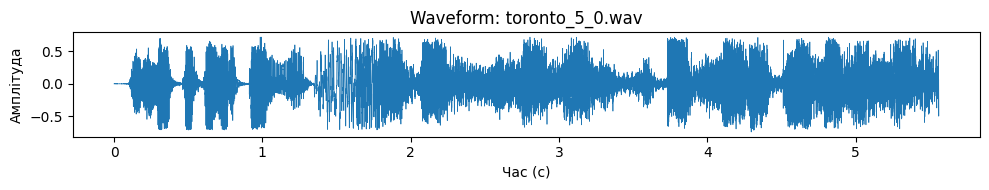

Тривалість: 5.56 с  |  Семплів: 88960


In [6]:
# --- Inspect: raw samples ---
print("=== 3 сирих записи зі словника ===")
for s in samples[:3]:
    print(f"  group : {s['group']}")
    print(f"  path  : {s['path']}")
    print(f"  text  : {s['text'][:80]}...")
    print()

# Waveform одного аудіо
sample_audio, _ = librosa.load(samples[0]["path"], sr=SAMPLE_RATE, mono=True)
fig, ax = plt.subplots(figsize=(10, 2))
ax.plot(np.linspace(0, len(sample_audio) / SAMPLE_RATE, len(sample_audio)), sample_audio, linewidth=0.5)
ax.set_xlabel("Час (с)")
ax.set_ylabel("Амплітуда")
ax.set_title(f"Waveform: {samples[0]['path'].split('/')[-1]}")
plt.tight_layout()
plt.show()
print(f"Тривалість: {len(sample_audio)/SAMPLE_RATE:.2f} с  |  Семплів: {len(sample_audio)}")

In [7]:
test_group_set = set(TEST_LINES)

all_groups = sorted(set(s["group"] for s in samples))
trainval_groups = [g for g in all_groups if g not in test_group_set]

random.shuffle(trainval_groups)
n_val = max(1, int(len(trainval_groups) * VAL_SPLIT))
val_group_set   = set(trainval_groups[:n_val])
train_group_set = set(trainval_groups[n_val:])

train_samples = [s for s in samples if s["group"] in train_group_set]
val_samples   = [s for s in samples if s["group"] in val_group_set]
test_samples  = [s for s in samples if s["group"] in test_group_set]

print(f"Groups  — train: {len(train_group_set)}, val: {len(val_group_set)}, test: {len(test_group_set)}")
print(f"Samples — train: {len(train_samples)}, val: {len(val_samples)}, test: {len(test_samples)}")

Groups  — train: 17, val: 2, test: 21
Samples — train: 4434, val: 465, test: 1736


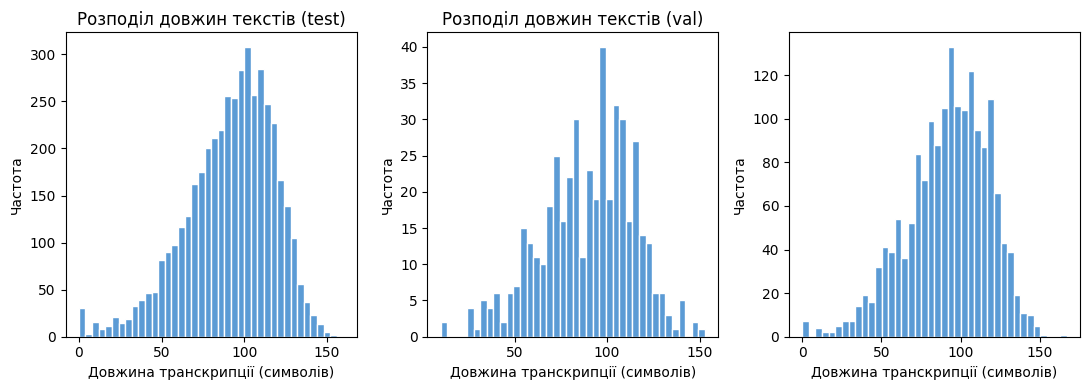

Середня довжина тексту (train): 91 символів
Середня довжина тексту (val): 89 символів
Середня довжина тексту (test): 92 символів


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(11, 4))

# Гістограма: довжина тексту (кількість символів) у train
train_text_lens = [len(s["text"]) for s in train_samples]
axes[0].hist(train_text_lens, bins=40, color="#5b9bd5", edgecolor="white")
axes[0].set_xlabel("Довжина транскрипції (символів)")
axes[0].set_ylabel("Частота")
axes[0].set_title("Розподіл довжин текстів (train)")

val_text_lens = [len(s["text"]) for s in val_samples]
axes[1].hist(val_text_lens, bins=40, color="#5b9bd5", edgecolor="white")
axes[1].set_xlabel("Довжина транскрипції (символів)")
axes[1].set_ylabel("Частота")
axes[1].set_title("Розподіл довжин текстів (val)")

test_text_lens = [len(s["text"]) for s in test_samples]
axes[2].hist(test_text_lens, bins=40, color="#5b9bd5", edgecolor="white")
axes[2].set_xlabel("Довжина транскрипції (символів)")
axes[2].set_ylabel("Частота")
axes[0].set_title("Розподіл довжин текстів (test)")

plt.tight_layout()
plt.show()
print(f"Середня довжина тексту (train): {np.mean(train_text_lens):.0f} символів")
print(f"Середня довжина тексту (val): {np.mean(val_text_lens):.0f} символів")
print(f"Середня довжина тексту (test): {np.mean(test_text_lens):.0f} символів")

## 3. Dataset, Collator & DataModule

In [9]:
class TorontoDataset(Dataset):
    def __init__(self, samples, processor, max_duration=MAX_DURATION):
        self.samples     = samples
        self.processor   = processor
        self.max_samples = int(max_duration * SAMPLE_RATE)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        audio, _ = librosa.load(item["path"], sr=SAMPLE_RATE, mono=True)
        audio = audio[: self.max_samples]  # clip to 30 s

        # return_attention_mask=True: 1 for real audio frames, 0 for silence-padded frames
        feat_out = self.processor.feature_extractor(
            audio,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
            return_attention_mask=True,
            padding="max_length",
            max_length=self.max_samples,
            truncation=True,
        )
        input_features = feat_out.input_features[0]   # (80, 3000)
        attention_mask = feat_out.attention_mask[0]    # (3000,)

        labels = self.processor.tokenizer(item["text"]).input_ids

        return {"input_features": input_features, "attention_mask": attention_mask, "labels": labels}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

=== Один елемент з Dataset ===
  input_features shape : torch.Size([80, 3000])  (mel-bins × time-frames)
  labels (token ids)   : [50258, 50363, 8068, 859, 9585, 32797, 12, 35723, 21768, 3842, 4677, 0, 36062, 6251, 776, 3634, 1784, 13, 3450, 1552, 29419, 1234, 10022, 1827, 14490, 29536, 13, 50257]
  labels decoded       : Свати́-повертальне! Новий сезон. Абсолютно нові серії.
  оригінальний текст   : Свати́-повертальне! Новий сезон. Абсолютно нові серії.


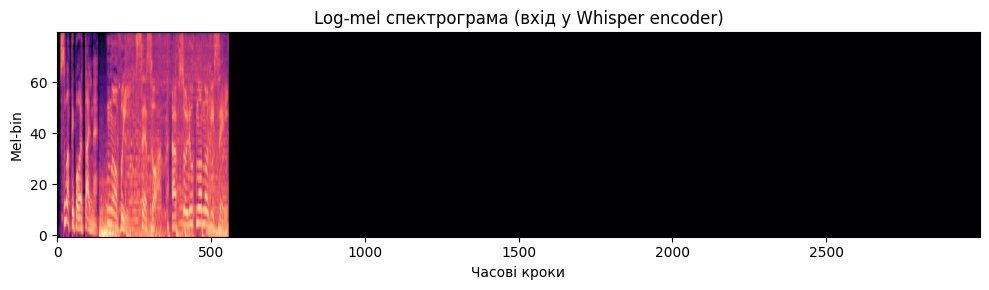

In [10]:
# --- Inspect: Dataset.__getitem__ ---
# Потрібен processor — якщо ще не завантажений, завантажуємо тимчасово
try:
    processor
except NameError:
    from transformers import WhisperProcessor
    processor = WhisperProcessor.from_pretrained(MODEL_NAME)

_ds = TorontoDataset(train_samples[:1], processor)
_item = _ds[0]

print("=== Один елемент з Dataset ===")
print(f"  input_features shape : {_item['input_features'].shape}  (mel-bins × time-frames)")
print(f"  labels (token ids)   : {_item['labels']}")
print(f"  labels decoded       : {processor.tokenizer.decode(_item['labels'], skip_special_tokens=True)}")
print(f"  оригінальний текст   : {train_samples[0]['text']}")

# Mel-спектрограма
fig, ax = plt.subplots(figsize=(10, 3))
ax.imshow(_item["input_features"].numpy(), origin="lower", aspect="auto", cmap="magma")
ax.set_xlabel("Часові кроки")
ax.set_ylabel("Mel-bin")
ax.set_title("Log-mel спектрограма (вхід у Whisper encoder)")
plt.tight_layout()
plt.show()

In [11]:
class CollateFn:
    """Клас замість closure — тільки клас можна pickle для num_workers > 0 на macOS."""
    def __init__(self, processor):
        self.processor = processor

    def __call__(self, batch):
        feat_batch  = [{"input_features": b["input_features"]} for b in batch]
        label_batch = [{"input_ids": b["labels"]} for b in batch]

        padded_inputs = self.processor.feature_extractor.pad(feat_batch, return_tensors="pt")
        padded_labels = self.processor.tokenizer.pad(label_batch, return_tensors="pt")

        labels = padded_labels["input_ids"].masked_fill(
            padded_labels["attention_mask"].ne(1), -100
        )
        # Stack attention masks (all already (3000,) — same size, no padding needed)
        attention_mask = torch.stack([b["attention_mask"] for b in batch])

        return {
            "input_features": padded_inputs.input_features,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [12]:
# --- Inspect: DataLoader batch ---
_loader = DataLoader(
    TorontoDataset(train_samples[:4000], processor),
    batch_size=4,
    collate_fn=CollateFn(processor),
    num_workers=NUM_WORKERS,
)
_batch = next(iter(_loader))

print("=== Один батч з DataLoader ===")
print(f"  input_features shape : {_batch['input_features'].shape}  (batch × mel-bins × time-frames)")
print(f"  labels shape         : {_batch['labels'].shape}  (batch × max_seq_len)")
print()
print("  labels з -100 (другий семпл у батчі):")
print(f"    {_batch['labels'][1].tolist()}")
print()
print("  Де -100 (padding-позиції):", (_batch["labels"][1] == -100).sum().item(), "токенів")
print("  Реальні токени          :", (_batch["labels"][1] != -100).sum().item(), "токенів")
print()
_real = _batch["labels"][1].masked_fill(_batch["labels"][1].eq(-100), processor.tokenizer.pad_token_id)
print("  Текст другого семплу:", processor.tokenizer.decode(_real, skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


=== Один батч з DataLoader ===
  input_features shape : torch.Size([4, 80, 3000])  (batch × mel-bins × time-frames)
  labels shape         : torch.Size([4, 55])  (batch × max_seq_len)

  labels з -100 (другий семпл у батчі):
    [50258, 50363, 8578, 6325, 1885, 29536, 26622, 1827, 47469, 0, 50257, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]

  Де -100 (padding-позиції): 44 токенів
  Реальні токени          : 11 токенів

  Текст другого семплу: В Росії радіють!


In [13]:
class TorontoDataModule(pl.LightningDataModule):
    def __init__(self, train_s, val_s, test_s, processor, batch_size=BATCH_SIZE):
        super().__init__()
        self.train_s    = train_s
        self.val_s      = val_s
        self.test_s     = test_s
        self.processor  = processor
        self.batch_size = batch_size
        self._collate   = CollateFn(processor)

    def setup(self, stage=None):
        self.train_ds = TorontoDataset(self.train_s, self.processor)
        self.val_ds   = TorontoDataset(self.val_s,   self.processor)
        self.test_ds  = TorontoDataset(self.test_s,  self.processor)

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=self.batch_size,
                          shuffle=True,  collate_fn=self._collate, num_workers=NUM_WORKERS)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=self.batch_size,
                          shuffle=False, collate_fn=self._collate, num_workers=NUM_WORKERS)

    def test_dataloader(self):
        return DataLoader(self.test_ds, batch_size=self.batch_size,
                          shuffle=False, collate_fn=self._collate, num_workers=NUM_WORKERS)

In [14]:
from tqdm.auto import tqdm

def normalize_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def prepare_model(model, device=DEVICE):
    model = model.to(device)
    model.config.forced_decoder_ids    = None
    model.generation_config.suppress_tokens       = []
    model.generation_config.begin_suppress_tokens = []
    return model


def evaluate_model(model, processor, samples, batch_size=BATCH_SIZE, device=DEVICE, desc="Evaluating"):
    model.eval()
    forced_decoder_ids = processor.get_decoder_prompt_ids(language="uk", task="transcribe")
    loader = DataLoader(
        TorontoDataset(samples, processor),
        batch_size=batch_size,
        collate_fn=CollateFn(processor),
        num_workers=NUM_WORKERS,
    )
    all_preds, all_refs = [], []
    pad_id = processor.tokenizer.pad_token_id

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, unit="batch"):
            feats = batch["input_features"].to(device)
            mask  = batch["attention_mask"].to(device)
            pred_ids = model.generate(
                feats,
                attention_mask=mask,
                forced_decoder_ids=forced_decoder_ids,
            )
            preds      = processor.batch_decode(pred_ids, skip_special_tokens=True)
            raw_labels = batch["labels"].masked_fill(batch["labels"].eq(-100), pad_id)
            refs       = processor.batch_decode(raw_labels, skip_special_tokens=True)
            all_preds.extend(normalize_text(p) for p in preds)
            all_refs.extend(normalize_text(r) for r in refs)

    return {
        "WER": wer(all_refs, all_preds),
        "CER": cer(all_refs, all_preds),
        "predictions": all_preds[:5],
        "references":  all_refs[:5],
    }

## 4. Baseline Evaluation (original whisper-small, no fine-tuning)

In [15]:
original_save_path = SAVE_DIR / "whisper-small-original"

# if original_save_path.exists():
#     print(f"Завантажуємо базову модель локально з {original_save_path}...")
#     processor      = WhisperProcessor.from_pretrained(original_save_path)
#     baseline_model = WhisperForConditionalGeneration.from_pretrained(original_save_path)
# else:
print(f"Завантажуємо базову модель з HuggingFace: {MODEL_NAME}...")
processor      = WhisperProcessor.from_pretrained(MODEL_NAME)
baseline_model = WhisperForConditionalGeneration.from_pretrained(MODEL_NAME)
# Зберігаємо локально щоб наступного разу не завантажувати знову
baseline_model.save_pretrained(original_save_path)
processor.save_pretrained(original_save_path)
print(f"Оригінальна модель збережена → {original_save_path}")

baseline_model = prepare_model(baseline_model, DEVICE)
print(f"Модель на девайсі: {DEVICE}")

print(f"\nEvaluating baseline on {len(test_samples[:400])} test samples...")
baseline_metrics = evaluate_model(
    baseline_model, processor, test_samples[:400], desc="Baseline eval"
)

print(f"\nBaseline WER : {baseline_metrics['WER']*100:.2f}%")
print(f"Baseline CER : {baseline_metrics['CER']*100:.2f}%")
print("\nSample predictions:")
for ref, pred in zip(baseline_metrics["references"], baseline_metrics["predictions"]):
    print(f"  REF : {ref}")
    print(f"  PRED: {pred}")
    print()

Завантажуємо базову модель з HuggingFace: openai/whisper-small...


model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Оригінальна модель збережена → /content/drive/MyDrive/audio lab 3/whisper_ckpts/whisper-small-original
Модель на девайсі: cuda

Evaluating baseline on 400 test samples...


Baseline eval:   0%|          | 0/50 [00:00<?, ?batch/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'tr


Baseline WER : 28.93%
Baseline CER : 13.00%

Sample predictions:
  REF : музичногостросоціальне святослав вакарчук та альона альона випустили спільний трек країна дітей присвячений дітям
  PRED: музичногостру соціальне світаслава керчук та аліона альона випустили спільний трек країна дітей присвячений дітям

  REF : які постраждали від війни на сході україни збройних конфліктів та терактів діти які які
  PRED: які постраждали від війни на сході україни зброїних конфліктів та терактів

  REF : пророслиииии в неееебо країни це справді достойна робота на важливу для україни тему і нам здається несправедливим
  PRED: це справді достойна робота наважливу для україни тему і нам здається несправедливе

  REF : що це відео трішки повільно набирає перегляди тому наполегливо радимо подивитися мимоволі навіть радієш що святослав вакарчук
  PRED: мимо волі навіть радіїш що святослава картюк

  REF : нарешті навчився писати тексти без дієслівних рим але потім дізнаєшся що слова вакарчука написав с

## 5. Fine-tuning with PyTorch Lightning

In [16]:
class WhisperModule(pl.LightningModule):
    def __init__(self, model_name=MODEL_NAME, lr=LR, freeze_encoder=FREEZE_ENCODER):
        super().__init__()
        self.save_hyperparameters()
        self.processor = WhisperProcessor.from_pretrained(model_name)
        self.model     = WhisperForConditionalGeneration.from_pretrained(model_name)
        self.model.config.forced_decoder_ids    = None
        self.model.generation_config.suppress_tokens       = []
        self.model.generation_config.begin_suppress_tokens = []
        self.lr = lr

        self.model.gradient_checkpointing_enable()

        if freeze_encoder:
            for param in self.model.model.encoder.parameters():
                param.requires_grad = False

        self.model.train()
        self._val_preds, self._val_refs = [], []

    def forward(self, input_features, attention_mask, labels):
        return self.model(
            input_features=input_features,
            attention_mask=attention_mask,
            labels=labels,
        )

    def training_step(self, batch, batch_idx):
        loss = self(batch["input_features"], batch["attention_mask"], batch["labels"]).loss
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self(batch["input_features"], batch["attention_mask"], batch["labels"]).loss
        self.log("val_loss", loss, on_step=False, on_epoch=True, prog_bar=True)

        forced_decoder_ids = self.processor.get_decoder_prompt_ids(language="uk", task="transcribe")
        pred_ids = self.model.generate(
            batch["input_features"],
            attention_mask=batch["attention_mask"],
            forced_decoder_ids=forced_decoder_ids,
        )
        pad_id = self.processor.tokenizer.pad_token_id
        preds  = self.processor.batch_decode(pred_ids, skip_special_tokens=True)
        refs   = self.processor.batch_decode(
            batch["labels"].masked_fill(batch["labels"].eq(-100), pad_id),
            skip_special_tokens=True,
        )
        self._val_preds.extend(normalize_text(p) for p in preds)
        self._val_refs.extend(normalize_text(r) for r in refs)

    def on_validation_epoch_end(self):
        if self._val_refs:
            self.log("val_wer", wer(self._val_refs, self._val_preds), prog_bar=True)
            self.log("val_cer", cer(self._val_refs, self._val_preds))
        self._val_preds.clear()
        self._val_refs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, self.parameters()), lr=self.lr
        )
        scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=0.1, end_factor=1.0, total_iters=3
        )
        return [optimizer], [{"scheduler": scheduler, "interval": "epoch"}]

In [17]:
class MetricsHistory(pl.Callback):
    """Stores per-epoch metrics for plotting."""
    def __init__(self):
        self.train_loss = []
        self.val_loss   = []
        self.val_wer    = []
        self.val_cer    = []

    def _get(self, trainer, key):
        v = trainer.callback_metrics.get(key)
        return float(v) if v is not None else float("nan")

    def on_train_epoch_end(self, trainer, pl_module):
        self.train_loss.append(self._get(trainer, "train_loss"))

    def on_validation_epoch_end(self, trainer, pl_module):
        self.val_loss.append(self._get(trainer, "val_loss"))
        self.val_wer.append(self._get(trainer, "val_wer"))
        self.val_cer.append(self._get(trainer, "val_cer"))

In [18]:
# Звільняємо памʼять GPU від baseline моделі перед тренуванням
import gc

if "baseline_model" in dir():
    baseline_model.cpu()
    del baseline_model
    gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Памʼять очищено. Починаємо тренування...")

Памʼять очищено. Починаємо тренування...


In [19]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

whisper_module = WhisperModule(model_name=MODEL_NAME, lr=LR)
data_module    = TorontoDataModule(train_samples[:4000], val_samples[:400], test_samples, processor)
metrics_cb     = MetricsHistory()

checkpoint_cb = ModelCheckpoint(
    dirpath=str(SAVE_DIR / "checkpoints"),
    filename="whisper-{epoch:02d}-wer{val_wer:.3f}",
    monitor="val_wer",
    mode="min",
    save_top_k=1,
)

early_stop_cb = EarlyStopping(
    monitor="val_wer", patience=3, mode="min", verbose=True
)

trainer = pl.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed" if torch.cuda.is_available() else 32,
    callbacks=[checkpoint_cb, early_stop_cb, metrics_cb],
    num_sanity_val_steps=0,
    log_every_n_steps=10,
)

trainer.fit(whisper_module, datamodule=data_module)

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ WhisperForConditionalGeneration │  241 M │ train │     0 │
└───┴───────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 153 M                                                                                            
Non-trainable params: 88.2 M                                                                                       
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966                                                                        
Modules in train mode: 350                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`use_cache = True` is incompatible with gradient checkpointing. Setting `use_cache = False`...
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_wer improved. New best score: 0.258
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_wer improved by 0.027 >= min_delta = 0.0. New best score: 0.231
INFO:pytorch_lightning.callbacks.early_stopping:Metric val_wer improved by 0.009 >= min_delta = 0.0. New best score: 0.222
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


## 6. Save & Evaluate Fine-tuned Model

In [20]:
# Load best checkpoint and save as HuggingFace model
best_ckpt = checkpoint_cb.best_model_path
print(f"Best checkpoint: {best_ckpt}")

ft_module = WhisperModule.load_from_checkpoint(best_ckpt)

save_path = SAVE_DIR / "whisper-small-finetuned"
ft_module.model.save_pretrained(save_path)
ft_module.processor.save_pretrained(save_path)
print(f"Model saved to: {save_path}")

Best checkpoint: /content/drive/.shortcut-targets-by-id/1LkVqCSHYGOWkCKfYs4ULB_HRRi-dAnrF/audio lab 3/whisper_ckpts/checkpoints/whisper-epoch=02-werval_wer=0.222.ckpt


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: /content/drive/MyDrive/audio lab 3/whisper_ckpts/whisper-small-finetuned


In [21]:
ft_module.model = prepare_model(ft_module.model, DEVICE)

print(f"Evaluating fine-tuned model on {len(test_samples[:400])} test samples...")
ft_metrics = evaluate_model(
    ft_module.model, processor, test_samples[:400], desc="Fine-tuned eval"
)

print(f"\nFine-tuned WER : {ft_metrics['WER']*100:.2f}%")
print(f"Fine-tuned CER : {ft_metrics['CER']*100:.2f}%")

if "baseline_metrics" in dir():
    print()
    print(f"Improvement WER: {(baseline_metrics['WER'] - ft_metrics['WER'])*100:+.2f} pp")
    print(f"Improvement CER: {(baseline_metrics['CER'] - ft_metrics['CER'])*100:+.2f} pp")
else:
    print("\n(Baseline metrics not available — run section 4 first for comparison)")

print("\nSample predictions:")
for ref, pred in zip(ft_metrics["references"], ft_metrics["predictions"]):
    print(f"  REF : {ref}")
    print(f"  PRED: {pred}")
    print()

Evaluating fine-tuned model on 400 test samples...


Fine-tuned eval:   0%|          | 0/50 [00:00<?, ?batch/s]


Fine-tuned WER : 24.83%
Fine-tuned CER : 8.50%

Improvement WER: +4.10 pp
Improvement CER: +4.50 pp

Sample predictions:
  REF : музичногостросоціальне святослав вакарчук та альона альона випустили спільний трек країна дітей присвячений дітям
  PRED: музичногостру соціальне світаслава керчук та аліона аліона випустили спільний трек країна дітей присвячений дітям

  REF : які постраждали від війни на сході україни збройних конфліктів та терактів діти які які
  PRED: які постраждали від війни на сході україни зброїних конфліктів та терактів тіти які

  REF : пророслиииии в неееебо країни це справді достойна робота на важливу для україни тему і нам здається несправедливим
  PRED: правді вне по країни це справді достойна робота наважливу для україни тему і нам здається несправедливе

  REF : що це відео трішки повільно набирає перегляди тому наполегливо радимо подивитися мимоволі навіть радієш що святослав вакарчук
  PRED: що це відео трішки повільно набирає перегляди тому наполегливо рад

## 7. Comparison Plots

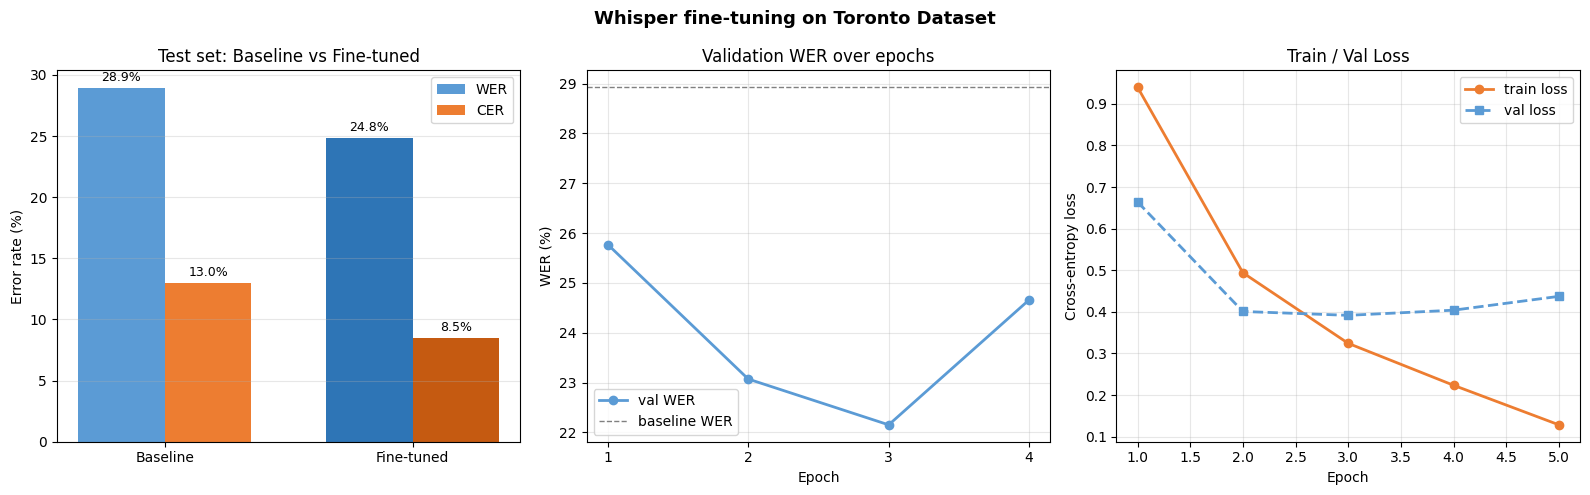

Plot saved → /content/drive/MyDrive/audio lab 3/whisper_ckpts/comparison.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Whisper fine-tuning on Toronto Dataset", fontsize=13, fontweight="bold")

# --- Plot 1: Baseline vs Fine-tuned WER / CER ---
ax = axes[0]
labels   = ["Baseline", "Fine-tuned"]
wer_vals = [baseline_metrics["WER"] * 100, ft_metrics["WER"] * 100]
cer_vals = [baseline_metrics["CER"] * 100, ft_metrics["CER"] * 100]
x     = np.arange(2)
width = 0.35
bars_wer = ax.bar(x - width / 2, wer_vals, width, label="WER", color=["#5b9bd5", "#2e75b6"])
bars_cer = ax.bar(x + width / 2, cer_vals, width, label="CER", color=["#ed7d31", "#c55a11"])
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Error rate (%)")
ax.set_title("Test set: Baseline vs Fine-tuned")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar in list(bars_wer) + list(bars_cer):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.3, f"{h:.1f}%",
            ha="center", va="bottom", fontsize=9)

# --- Plot 2: Validation WER per epoch ---
ax = axes[1]
val_wer_pct = [v * 100 for v in metrics_cb.val_wer if not np.isnan(v)]
if val_wer_pct:
    epochs = list(range(1, len(val_wer_pct) + 1))
    ax.plot(epochs, val_wer_pct, "o-", color="#5b9bd5", linewidth=2, label="val WER")
    ax.axhline(baseline_metrics["WER"] * 100, color="gray", linestyle="--",
               linewidth=1, label="baseline WER")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("WER (%)")
    ax.set_title("Validation WER over epochs")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(epochs)

# --- Plot 3: Train / Val Loss per epoch ---
ax = axes[2]
train_loss_vals = [v for v in metrics_cb.train_loss if not np.isnan(v)]
val_loss_vals   = [v for v in metrics_cb.val_loss   if not np.isnan(v)]
if train_loss_vals:
    ax.plot(range(1, len(train_loss_vals) + 1), train_loss_vals,
            "o-", color="#ed7d31", linewidth=2, label="train loss")
if val_loss_vals:
    ax.plot(range(1, len(val_loss_vals) + 1), val_loss_vals,
            "s--", color="#5b9bd5", linewidth=2, label="val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Train / Val Loss")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plot_path = SAVE_DIR / "comparison.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved → {plot_path}")

In [23]:
print("="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"Model : {MODEL_NAME}")
print(f"Train : {len(train_samples)} samples ({len(train_group_set)} groups)")
print(f"Val   : {len(val_samples)} samples ({len(val_group_set)} groups)")
print(f"Test  : {len(test_samples)} samples ({len(test_group_set)} groups)")
print()
print(f"{'Metric':<10} {'Baseline':>12} {'Fine-tuned':>12} {'Delta':>10}")
print("-" * 46)
for m in ["WER", "CER"]:
    b = baseline_metrics[m] * 100
    f = ft_metrics[m] * 100
    print(f"{m:<10} {b:>11.2f}% {f:>11.2f}% {f-b:>+9.2f} pp")
print("="*50)

FINAL SUMMARY
Model : openai/whisper-small
Train : 4434 samples (17 groups)
Val   : 465 samples (2 groups)
Test  : 1736 samples (21 groups)

Metric         Baseline   Fine-tuned      Delta
----------------------------------------------
WER              28.93%       24.83%     -4.10 pp
CER              13.00%        8.50%     -4.50 pp
